# Notebook 4: Data Loading & EDA (Classification)

## Heart Disease Prediction

**Goal**: Predict whether a patient has heart disease based on clinical features.

We're now switching from regression to **classification** — instead of predicting
a number, we're predicting a category (heart disease: yes or no).

Data Science Lifecycle (Classification Track):
1. **Data Loading & EDA** ← we are here
2. Preprocessing
3. Model Training & Evaluation
4. Model Comparison & Insights

---

### Why this dataset?
- Real medical data from the UCI Machine Learning Repository
- Classic binary classification problem
- Small enough to learn from, but realistic
- Mix of numerical and categorical features

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded!')

Libraries loaded!


## 1. Load the Data

In [2]:
# load the heart disease dataset
df = pd.read_csv('../data/heart_disease.csv')

print(f'Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns')
df.head()

Dataset shape: 303 rows, 14 columns


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


### What do these columns mean?

| Column | Description | Type |
|--------|------------|------|
| age | Age in years | Numerical |
| sex | 1 = male, 0 = female | Categorical |
| cp | Chest pain type (0-3) | Categorical |
| trestbps | Resting blood pressure (mm Hg) | Numerical |
| chol | Serum cholesterol (mg/dl) | Numerical |
| fbs | Fasting blood sugar > 120 mg/dl (1 = true) | Categorical |
| restecg | Resting ECG results (0-2) | Categorical |
| thalach | Maximum heart rate achieved | Numerical |
| exang | Exercise-induced angina (1 = yes) | Categorical |
| oldpeak | ST depression induced by exercise | Numerical |
| slope | Slope of peak exercise ST segment | Categorical |
| ca | Number of major vessels colored by fluoroscopy (0-3) | Numerical |
| thal | Thalassemia (1 = normal, 2 = fixed defect, 3 = reversible) | Categorical |
| **target** | **1 = heart disease, 0 = no heart disease** | **Target** |

## 2. Basic Data Inspection

In [3]:
# data types
print('--- Data Types ---')
print(df.dtypes)
print()

# missing values
print('--- Missing Values ---')
print(df.isnull().sum())
print(f'\nTotal missing: {df.isnull().sum().sum()}')

--- Data Types ---
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

--- Missing Values ---
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Total missing: 0


In [4]:
# basic statistics
df.describe().round(2)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00
mean,54.37,0.68,0.97,131.62,246.26,0.15,0.53,149.65,0.33,1.04,1.40,0.73,2.31,0.54
std,9.08,0.47,1.03,17.54,51.83,0.36,0.53,22.91,0.47,1.16,0.62,1.02,0.61,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,47.50,0.00,0.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,1.00,0.00,2.00,0.00
50%,55.00,1.00,1.00,130.00,240.00,0.00,1.00,153.00,0.00,0.80,1.00,0.00,2.00,1.00
75%,61.00,1.00,2.00,140.00,274.50,0.00,1.00,166.00,1.00,1.60,2.00,1.00,3.00,1.00
max,77.00,1.00,3.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,2.00,4.00,3.00,1.00


## 3. Target Variable Analysis

In classification, the first thing to check is: **is the target balanced?**
If one class is much more common, we might need special handling.

Target distribution:
  Heart disease (1): 165 (54.5%)
  No disease (0):    138 (45.5%)


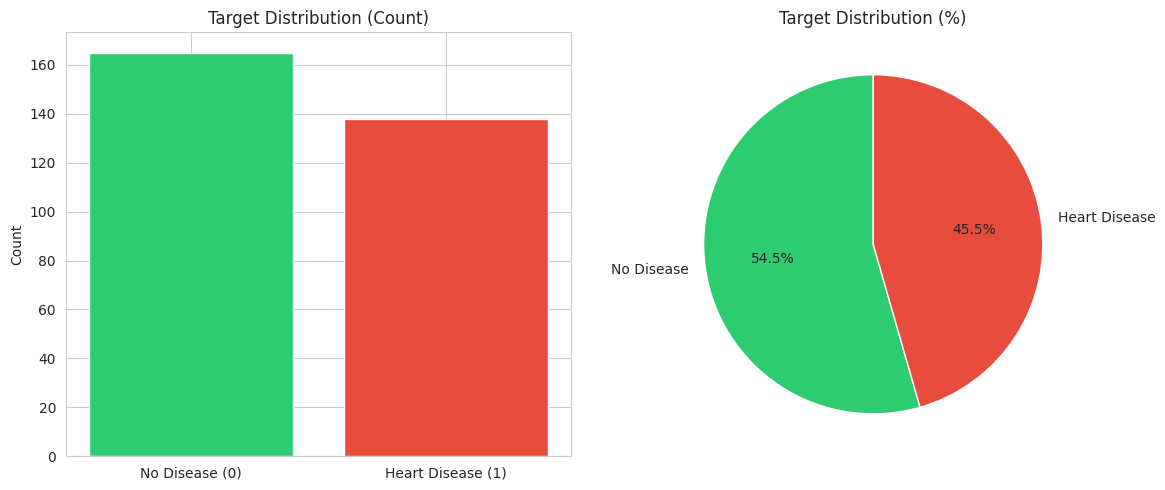


The dataset is fairly balanced — good! No need for special resampling.


In [5]:
# target distribution
target_counts = df['target'].value_counts()
print('Target distribution:')
print(f'  Heart disease (1): {target_counts[1]} ({target_counts[1]/len(df)*100:.1f}%)')
print(f'  No disease (0):    {target_counts[0]} ({target_counts[0]/len(df)*100:.1f}%)')

# plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# bar chart
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(['No Disease (0)', 'Heart Disease (1)'], target_counts.values, color=colors)
axes[0].set_title('Target Distribution (Count)')
axes[0].set_ylabel('Count')

# pie chart
axes[1].pie(target_counts.values, labels=['No Disease', 'Heart Disease'], 
            colors=colors, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Target Distribution (%)')

plt.tight_layout()
plt.savefig('../images/04_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nThe dataset is fairly balanced — good! No need for special resampling.')

## 4. Feature Distributions by Target

Let's see how features differ between patients with and without heart disease.

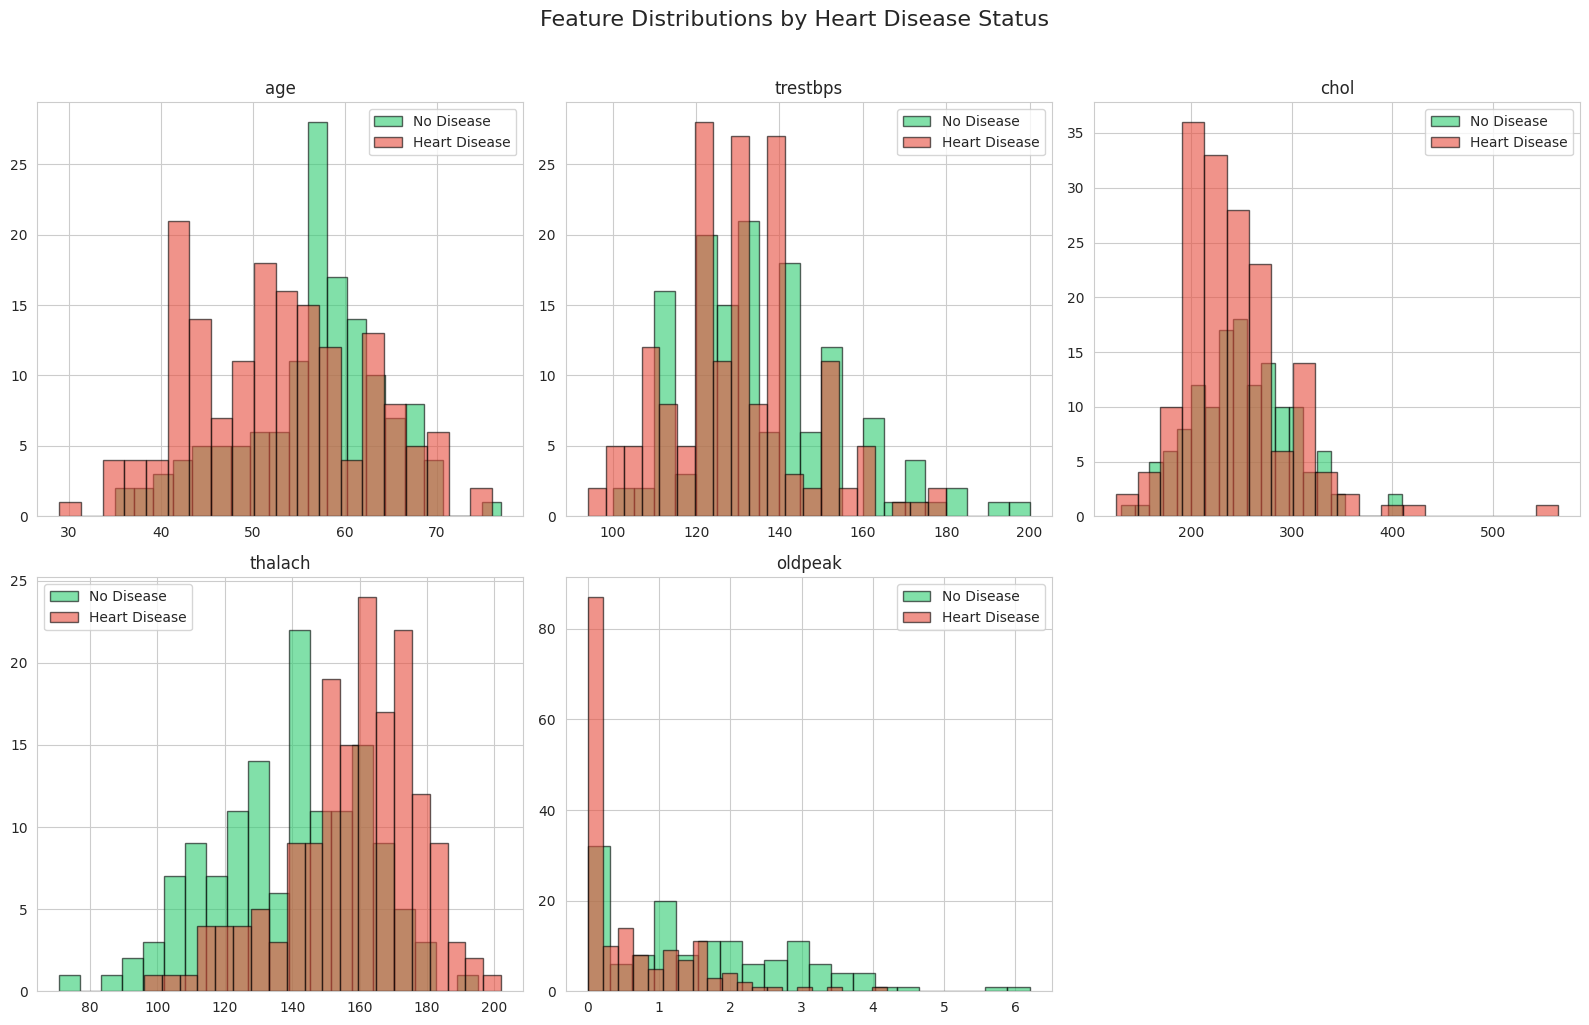

In [6]:
# numerical features distribution by target
num_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(num_features):
    for target_val, color, label in [(0, '#2ecc71', 'No Disease'), (1, '#e74c3c', 'Heart Disease')]:
        subset = df[df['target'] == target_val][col]
        axes[i].hist(subset, bins=20, alpha=0.6, color=color, label=label, edgecolor='black')
    axes[i].set_title(col)
    axes[i].legend()

# hide the empty subplot
axes[5].set_visible(False)

plt.suptitle('Feature Distributions by Heart Disease Status', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('../images/04_feature_by_target.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Categorical Features Analysis

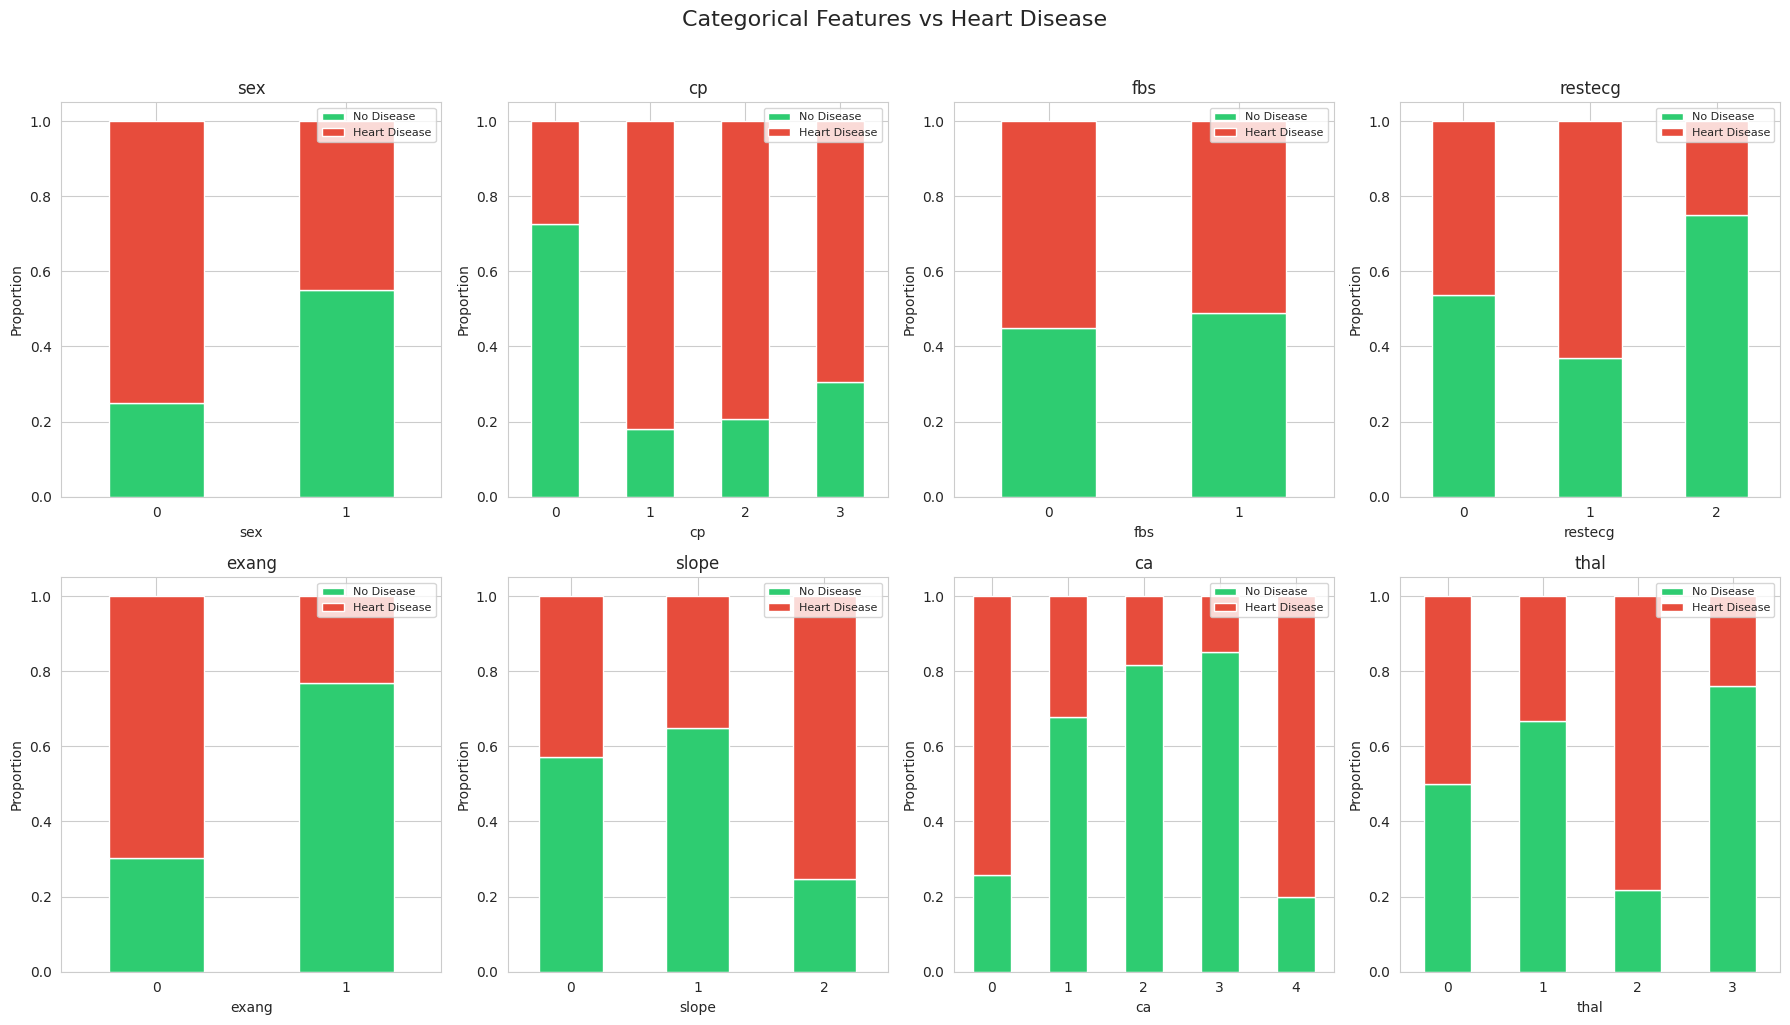

In [7]:
# categorical features vs target
cat_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    ct = pd.crosstab(df[col], df['target'], normalize='index')
    ct.plot(kind='bar', ax=axes[i], color=['#2ecc71', '#e74c3c'], stacked=True)
    axes[i].set_title(col)
    axes[i].set_ylabel('Proportion')
    axes[i].legend(['No Disease', 'Heart Disease'], fontsize=8)
    axes[i].tick_params(axis='x', rotation=0)

plt.suptitle('Categorical Features vs Heart Disease', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('../images/04_categorical_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Correlation Analysis

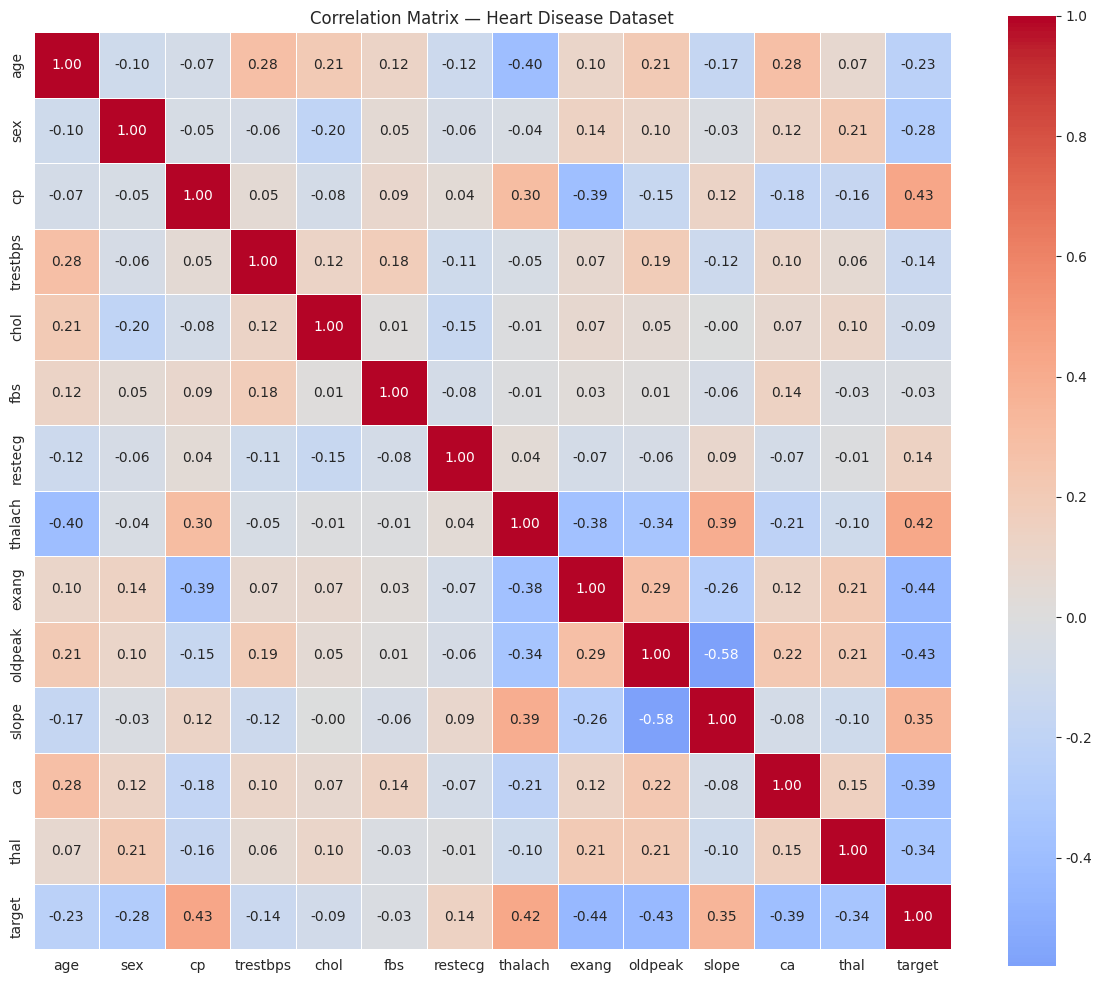

Correlation with target (heart disease):
exang      -0.44
oldpeak    -0.43
cp          0.43
thalach     0.42
ca         -0.39
slope       0.35
thal       -0.34
sex        -0.28
age        -0.23
restecg     0.14
trestbps   -0.14
chol       -0.09
fbs        -0.03
Name: target, dtype: float64


In [8]:
# correlation matrix
corr = df.corr().round(2)

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, fmt='.2f')
plt.title('Correlation Matrix — Heart Disease Dataset')
plt.tight_layout()
plt.savefig('../images/04_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# features most correlated with target
print('Correlation with target (heart disease):')
target_corr = corr['target'].drop('target').sort_values(key=abs, ascending=False)
print(target_corr)

## 7. Key Takeaways from EDA

1. **Dataset is balanced** — roughly 54% have heart disease, 46% don't
2. **No missing values** — clean dataset
3. **Chest pain type (cp)** is strongly associated with heart disease
4. **Max heart rate (thalach)** is higher in patients with heart disease
5. **Exercise-induced angina (exang)** is a strong indicator
6. **Oldpeak** (ST depression) is higher in patients without heart disease
7. **Age** alone is not a strong predictor — other factors matter more

### Next Steps
In the next notebook, we'll preprocess this data and train classification models!